In [1]:
import random

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset



# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# RDKit for SMILES parsing and descriptors
from rdkit import Chem, RDLogger
from rdkit.Chem import BRICS, Descriptors, rdMolDescriptors, rdPartialCharges
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams

# FINGERPRINTS from scikit-fingerprints
from skfp.fingerprints import (
    ECFPFingerprint,
    MACCSFingerprint,
    PubChemFingerprint,
    FunctionalGroupsFingerprint,
)

# PyTorch Geometric for graph branch in ensemble
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as GeometricDataLoader
from torch_geometric.nn import GINEConv, global_mean_pool

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import MinMaxScaler

RDLogger.DisableLog("rdApp.*")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("✓ All dependencies loaded successfully (Optuna enabled)")

<frozen importlib._bootstrap>:488: RuntimeWarning: to-Python converter for boost::shared_ptr<RDKit::FilterMatcherBase> already registered; second conversion method ignored.


✓ All dependencies loaded successfully (Optuna enabled)


In [2]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from collections import Counter
from joblib import Parallel, delayed
import pandas as pd

In [3]:
# ==========================================
# 1. PARSER HIERARCHII (.obo -> Mapowanie)
# ==========================================
def parse_obo_hierarchy(obo_path, target_cols):
    name_to_idx = {name: i for i, name in enumerate(target_cols)}
    hierarchy_pairs = []
    curr_id = None
    try:
        with open(obo_path, "r") as f:
            for line in f:
                line = line.strip()
                if line.startswith("id: "):
                    curr_id = line.split("id: ")[1]
                elif line.startswith("is_a: "):
                    parent_id = line.split("is_a: ")[1].split(" ! ")[0]
                    if curr_id in name_to_idx and parent_id in name_to_idx:
                        hierarchy_pairs.append((name_to_idx[curr_id], name_to_idx[parent_id]))
        print(f"Załadowano {len(hierarchy_pairs)} relacji hierarchicznych.")
    except Exception as e:
        print(f"Błąd parsera OBO: {e}")
    return hierarchy_pairs


def build_hierarchy_structure(hierarchy_pairs, num_classes):
    """
    Buduje strukturę hierarchii: children_map (dla każdej klasy rodzice)
    oraz parent_map (dla każdej klasy dzieci).
    """
    children = [[] for _ in range(num_classes)]
    parents = [[] for _ in range(num_classes)]

    for child_idx, parent_idx in hierarchy_pairs:
        children[parent_idx].append(child_idx)
        parents[child_idx].append(parent_idx)

    return children, parents


# ==========================================
# 2. FUNKCJA FILTRUJĄCA SMILES
# ==========================================
def filter_invalid_smiles(smiles_list, y_labels=None, return_bad_indices=False):
    valid_indices, bad_indices = [], []
    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            valid_indices.append(i)
        else:
            bad_indices.append(i)

    valid_indices = np.array(valid_indices)
    bad_indices = np.array(bad_indices)
    filtered_smiles = [smiles_list[i] for i in valid_indices]

    print(f"Filtrowanie: {len(smiles_list)} -> {len(filtered_smiles)}")

    result = [filtered_smiles]
    if y_labels is not None:
        result.append(y_labels[valid_indices])
    if return_bad_indices:
        result.append(bad_indices)
    return tuple(result) if len(result) > 1 else result[0]


# ==========================================
# 3. ARCHITEKTURA: HMCN (Hierarchical Multi-Label Classification Network)
# ==========================================
class ResBlock(nn.Module):
    def __init__(self, size, dropout=0.2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(size, size),
            nn.BatchNorm1d(size),
        )

    def forward(self, x):
        return F.relu(x + self.block(x))


class ConstrainedOutputLayer(nn.Module):
    """
    Warstwa wyjściowa z ograniczeniami hierarchii.
    Wymusza: P(parent) >= max(P(all_children))

    UWAGA: Używana tylko w inference/evaluation, nie podczas treningowania!
    """

    def __init__(self, hierarchy_children, num_classes, device):
        super().__init__()
        self.hierarchy_children = hierarchy_children
        self.num_classes = num_classes
        self.device = device

    def forward(self, probs):
        """
        probs: [batch_size, num_classes] już obliczone prawdopodobieństwa (nie logity!)
        Zwraca: [batch_size, num_classes] ograniczone prawdopodobieństwa

        UWAGA: Ta operacja nie wspiera gradientów! Używać tylko w inference.
        """
        with torch.no_grad():
            probs = probs.clone()

            # Iteracyjnie wymuszaj ograniczenia hierarchii
            for _ in range(3):
                for parent_idx, children_indices in enumerate(self.hierarchy_children):
                    if children_indices:
                        max_child_prob = probs[:, children_indices].max(dim=1)[0]
                        probs[:, parent_idx] = torch.max(probs[:, parent_idx], max_child_prob)

        return probs


class HMCN(nn.Module):
    """
    Hierarchical Multi-Label Classification Network
    - Shared stem (feature extraction)
    - Residual blocks
    - Output head with hierarchy constraints
    """

    def __init__(
        self,
        input_size,
        num_classes,
        hierarchy_children=None,
        device=None,
        hidden_dim=1024,
        num_res_blocks=3,
        dropout=0.3,
        block_dropout=0.2,
    ):
        super().__init__()
        self.input_size = input_size
        self.num_classes = num_classes
        self.hierarchy_children = hierarchy_children or [[] for _ in range(num_classes)]
        self.device = device or torch.device("cpu")

        self.stem = nn.Sequential(
            nn.Linear(input_size, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
        )

        self.res_blocks = nn.ModuleList(
            [ResBlock(hidden_dim, dropout=block_dropout) for _ in range(num_res_blocks)]
        )
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_dim, num_classes)

        self.constraint_layer = ConstrainedOutputLayer(
            self.hierarchy_children,
            num_classes,
            self.device,
        )

    def forward(self, x, apply_constraints=None):
        """
        x: [batch_size, input_size]
        apply_constraints: czy zastosować ograniczenia hierarchii
                          - None (default): automatycznie (tylko w eval mode)
                          - True: zawsze stosuj
                          - False: nigdy nie stosuj
        Zwraca: [batch_size, num_classes] prawdopodobieństwa
        """
        x = self.stem(x)
        for block in self.res_blocks:
            x = block(x)
        x = self.dropout(x)

        logits = self.head(x)
        probs = torch.sigmoid(logits)

        if apply_constraints is None:
            apply_constraints = not self.training

        if apply_constraints:
            probs = self.constraint_layer(probs)

        return probs


# Dla wstecz kompatybilności
class ChEBIResNet(HMCN):
    """Alias do HMCN dla wstecz kompatybilności"""

    def __init__(self, input_size, num_classes, hierarchy_children=None, device=None, **kwargs):
        super().__init__(
            input_size=input_size,
            num_classes=num_classes,
            hierarchy_children=hierarchy_children,
            device=device,
            **kwargs,
        )

In [4]:
# ==========================================
# NARZĘDZIA: Utilities do pracy z hierarchią
# ==========================================

def check_hierarchy_violations(predictions, hierarchy_children, class_names=None):
    """
    Sprawdza naruszenia ograniczeń hierarchii.
    Naruszenie: dziecko=1 ale rodzic=0 (niemożliwe w hierarchii)
    
    predictions: [n_samples, n_classes] binary predictions
    hierarchy_children: List[List[int]] - dla każdej klasy indeksy dzieci
    class_names: optional nazwy klas dla raportu
    
    Returns:
    - violation_count: liczba całkowitych naruszeń
    - violation_pct: % próbek z naruszeniam
    """
    violations = 0
    violation_samples = set()
    
    for sample_idx in range(len(predictions)):
        for parent_idx, children_indices in enumerate(hierarchy_children):
            if children_indices and predictions[sample_idx, parent_idx] == 0:
                for child_idx in children_indices:
                    if predictions[sample_idx, child_idx] == 1:
                        violations += 1
                        violation_samples.add(sample_idx)
    
    violation_pct = (len(violation_samples) / len(predictions)) * 100
    
    print(f"\n=== RAPORT NARUSZEŃ HIERARCHII ===")
    print(f"Całkowita liczba naruszeń: {violations}")
    print(f"Próbek z nauszeniami: {len(violation_samples)} / {len(predictions)} ({violation_pct:.2f}%)")
    
    return violations, violation_pct

def get_class_depth(class_idx, hierarchy_parents):
    """
    Wylicza głębokość klasy w hierarchii (poziom od korzenia).
    """
    if not hierarchy_parents[class_idx]:
        return 0
    return 1 + max(get_class_depth(p, hierarchy_parents) for p in hierarchy_parents[class_idx])

def analyze_hierarchy_structure(hierarchy_children, hierarchy_parents, class_names=None):
    """
    Analizuje strukturę hierarchii.
    """
    num_classes = len(hierarchy_children)
    num_edges = sum(len(c) for c in hierarchy_children)
    
    # Węzły z rodzicami (nie-korzenie)
    roots = sum(1 for parents in hierarchy_parents if not parents)
    leaves = sum(1 for children in hierarchy_children if not children)
    
    # Głębokości
    depths = [get_class_depth(i, hierarchy_parents) for i in range(num_classes)]
    max_depth = max(depths) if depths else 0
    
    print(f"\n=== STATYSTYKI HIERARCHII ===")
    print(f"Liczba klas: {num_classes}")
    print(f"Liczba relacji is_a: {num_edges}")
    print(f"Korzenie (brak rodziców): {roots}")
    print(f"Liście (brak dzieci): {leaves}")
    print(f"Maksymalna głębokość: {max_depth}")
    print(f"Średnia głębokość: {np.mean(depths):.2f}")

In [5]:
# ==========================================
# TIE-BREAKER: Zaawansowana naprawa niespójności hierarchii
# ==========================================

def top_down_constraint_propagation(probs, hierarchy_children, hierarchy_parents, num_iterations=5):
    """
    Top-Down hierarchical constraint propagation.
    IDEA: Zaczyna od roots (węzły bez rodziców) i propaguje w dół:
    - P(dziecko) <= P(rodzic) dla każdej pary parent-child
    
    probs: [n_samples, n_classes] prawdopodobieństwa
    Modyfikuje in-place!
    """
    n_samples = probs.shape[0]
    
    for iteration in range(num_iterations):
        for sample_idx in range(n_samples):
            # Iteracyjnie wymuszaj constraints od parents do children
            for parent_idx, children_indices in enumerate(hierarchy_children):
                if children_indices:
                    parent_prob = probs[sample_idx, parent_idx]
                    # Dzieci nie mogą mieć wyższego prawdopodobieństwa niż rodzic
                    probs[sample_idx, children_indices] = np.minimum(
                        probs[sample_idx, children_indices],
                        parent_prob
                    )
            
            # W drugą stronę: jeśli dziecko ma wysokie p-stwo, rodzic musi też
            for child_idx, parent_indices in enumerate(hierarchy_parents):
                if parent_indices:
                    child_prob = probs[sample_idx, child_idx]
                    for parent_idx in parent_indices:
                        probs[sample_idx, parent_idx] = np.maximum(
                            probs[sample_idx, parent_idx],
                            child_prob
                        )
    
    return probs

def isotonic_regression_constraint(probs, hierarchy_children, hierarchy_parents, y_true=None):
    """
    Isotonic Regression approach do global hierarchy consistency.
    
    Jeśli mamy ground truth labels, możemy nauczyć się rankingu
    który respektuje hierarchię.
    
    probs: [n_samples, n_classes] raw probabilities
    y_true (optional): [n_samples, n_classes] ground truth labels
    """
    from sklearn.isotonic import IsotonicRegression
    
    n_samples, n_classes = probs.shape
    adjusted_probs = probs.copy()
    
    # Dla każdej klasy sprawdzamy czy hierarchy jest respektowana
    for class_idx in range(n_classes):
        # Znajdź rodziców i dzieci tej klasy
        parents = hierarchy_parents[class_idx]
        children = hierarchy_children[class_idx]
        
        if not parents and not children:
            continue  # Jest root/leaf, nie ma constraints
        
        # Isotonic regression na podstawie hierarchii
        ir = IsotonicRegression(increasing=True, out_of_bounds='clip')
        
        # Wagi: jeśli mamy labels, używamy ich, inaczej uniform
        if y_true is not None:
            sample_weight = y_true[:, class_idx].astype(float)
        else:
            sample_weight = None
        
        try:
            adjusted_probs[:, class_idx] = ir.fit_transform(
                probs[:, class_idx],
                sample_weight=sample_weight
            )
        except:
            pass  # Skip if IR fails
    
    return adjusted_probs

def hierarchical_tie_breaker(probs, hierarchy_children, hierarchy_parents, method='top-down', num_iterations=5):
    """
    Komprehensywny tie-breaker łączący różne metody.
    
    Methods:
    - 'top-down': Iteracyjna propagacja constraints z rodziców na dzieci
    - 'bottom-up': Iteracyjna propagacja constraints z dzieci na rodziców
    - 'bidirectional': Kombinacja obu (iteracyjna)
    - 'isotonic': Isotonic regression (wymaga ground truth)
    
    Returns: [n_samples, n_classes] naprawione prawdopodobieństwa
    """
    probs_fixed = probs.copy()
    
    if method == 'top-down':
        # Top-down: rodzice są "kotwicą", dzieci nie mogą ich przekroczyć
        for iteration in range(num_iterations):
            for parent_idx, children_indices in enumerate(hierarchy_children):
                if children_indices:
                    parent_prob = probs_fixed[:, parent_idx:parent_idx+1]  # [n_samples, 1]
                    probs_fixed[:, children_indices] = np.minimum(
                        probs_fixed[:, children_indices],
                        parent_prob
                    )
    
    elif method == 'bottom-up':
        # Bottom-up: dzieci "ciągną" rodziców w górę
        for iteration in range(num_iterations):
            for child_idx, parent_indices in enumerate(hierarchy_parents):
                if parent_indices:
                    child_prob = probs_fixed[:, child_idx:child_idx+1]  # [n_samples, 1]
                    for parent_idx in parent_indices:
                        probs_fixed[:, parent_idx] = np.maximum(
                            probs_fixed[:, parent_idx],
                            child_prob.flatten()
                        )
    
    elif method == 'bidirectional':
        # Kombinacja: iteracyjnie wymuszaj oba kierunki
        for iteration in range(num_iterations):
            # Top-down
            for parent_idx, children_indices in enumerate(hierarchy_children):
                if children_indices:
                    parent_prob = probs_fixed[:, parent_idx:parent_idx+1]
                    probs_fixed[:, children_indices] = np.minimum(
                        probs_fixed[:, children_indices],
                        parent_prob
                    )
            
            # Bottom-up
            for child_idx, parent_indices in enumerate(hierarchy_parents):
                if parent_indices:
                    child_prob = probs_fixed[:, child_idx:child_idx+1]
                    for parent_idx in parent_indices:
                        probs_fixed[:, parent_idx] = np.maximum(
                            probs_fixed[:, parent_idx],
                            child_prob.flatten()
                        )
    
    return probs_fixed

def analyze_pos_weight_effect(model, val_loader, hierarchy_children, device, target_cols):
    """
    Analizuje wpływ pos_weight na predykcje i consistency.
    Wyższa pos_weight -> silniejsze przewidywanie rare classes
    -> potencjalnie więcej niespójności hierarchii
    """
    model.eval()
    
    # Zbierz na validation set
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x = batch_x.to(device)
            preds = model(batch_x).cpu().numpy()
            labels = batch_y.numpy()
            
            all_preds.append(preds)
            all_labels.append(labels)
    
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    
    # Konwertuj na binary
    preds_binary = (preds > 0.5).astype(int)
    
    # Liczby niespójności
    violations, violation_pct = check_hierarchy_violations(preds_binary, hierarchy_children)
    
    # Statystyka predictions
    print(f"\n=== ANALIZA POS_WEIGHT EFFECT ===")
    print(f"Średnia p-stwo: {preds.mean():.4f}")
    print(f"Średnia predicted labels: {preds_binary.mean():.4f}")
    print(f"Średnia true labels: {labels.mean():.4f}")
    print(f"Max p-stwo: {preds.max():.4f}")
    print(f"Min p-stwo: {preds.min():.4f}")
    print(f"Niespójności hierarchii: {violations} ({violation_pct:.2f}% próbek)")
    print(f"Rarity scores per class: {preds.mean(axis=0)[:10]}")  # First 10 classes
    
    return preds, labels, preds_binary, violation_pct

def compare_tie_breaker_methods(probs, hierarchy_children, hierarchy_parents, target_cols):
    """
    Porównuje różne metody tie-breakera.
    """
    print("\n=== PORÓWNANIE METOD TIE-BREAKER ===")
    
    methods = ['top-down', 'bottom-up', 'bidirectional']
    results = {}
    
    for method in methods:
        probs_fixed = hierarchical_tie_breaker(
            probs, hierarchy_children, hierarchy_parents,
            method=method, num_iterations=5
        )
        preds = (probs_fixed > 0.5).astype(int)
        violations, violation_pct = check_hierarchy_violations(preds, hierarchy_children)
        
        results[method] = {
            'probs': probs_fixed,
            'violations': violations,
            'violation_pct': violation_pct,
            'avg_prob': probs_fixed.mean(),
            'max_prob': probs_fixed.max(),
            'min_prob': probs_fixed.min()
        }
        
        print(f"\n{method.upper()}:")
        print(f"  Niespójności: {violations} ({violation_pct:.2f}%)")
        print(f"  Średnie p-stwo: {probs_fixed.mean():.6f}")
        print(f"  Range: [{probs_fixed.min():.6f}, {probs_fixed.max():.6f}]")
    
    # Wybierz najlepszą metodę (najmniej violations)
    best_method = min(results.keys(), key=lambda m: results[m]['violation_pct'])
    print(f"\n✓ BEST METHOD: {best_method}")
    
    return results, best_method


In [6]:
# ==========================================
# 4. PRZYGOTOWANIE DANYCH I CECH
# ==========================================
print("Przygotowanie danych...")
train_df = pd.read_parquet("chebi_dataset_train.parquet")
target_cols = [c for c in train_df.columns if c not in ["mol_id", "SMILES"]]
X_train_raw = train_df["SMILES"].tolist()
y_train_raw = train_df[target_cols].values.astype(np.float32)

X_clean, y_clean = filter_invalid_smiles(X_train_raw, y_train_raw)

Przygotowanie danych...


Filtrowanie: 33668 -> 33658


In [7]:
print("Generowanie fingerprintów ChEBI (ECFP + MACCS + PubChem + FunctionalGroups + MolecularDescriptors)...")
from pathlib import Path

fp_cache_dir = Path("fingerprint_csv_cache")
fp_cache_dir.mkdir(exist_ok=True)

class MolecularDescriptorFeatures:
    feature_names = [
        "atomic_partial_charges_mean",
        "atomic_partial_charges_abs_mean",
        "atomic_partial_charges_min",
        "atomic_partial_charges_max",
        "number_of_rings",
        "num_aromatic_rings",
        "num_aliphatic_rings",
        "num_heterocycles",
        "tpsa",
        "labute_asa",
        "molecular_weight",
        "number_of_rotatable_bonds",
        "kappa1_index",
        "kappa2_index",
        "kappa3_index",
        "zagreb_index_m1",
        "zagreb_index_m2",
        "num_chiral_centers",
        "num_defined_chiral_centers",
        "atom_count_n",
        "atom_count_o",
        "atom_count_s",
        "atom_count_p",
        "atom_count_f",
        "atom_count_cl",
        "atom_count_br",
        "atom_count_i",
        "lipinski_filter",
        "pains_filter",
    ]

    def __init__(self):
        self.pains_catalog = None
        try:
            params = FilterCatalogParams()
            params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
            self.pains_catalog = FilterCatalog(params)
        except Exception:
            self.pains_catalog = None

    def transform(self, smiles_list):
        rows = []
        for smiles in smiles_list:
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                rows.append([0.0] * len(self.feature_names))
                continue

            charge_mean = 0.0
            charge_abs_mean = 0.0
            charge_min = 0.0
            charge_max = 0.0

            try:
                mol_h = Chem.AddHs(mol)
                rdPartialCharges.ComputeGasteigerCharges(mol_h)
                charges = []
                for atom in mol_h.GetAtoms():
                    if atom.HasProp("_GasteigerCharge"):
                        val = atom.GetProp("_GasteigerCharge")
                        if val not in ("nan", "-nan", "inf", "-inf"):
                            c = float(val)
                            if np.isfinite(c):
                                charges.append(c)

                if charges:
                    charges_arr = np.array(charges, dtype=np.float32)
                    charge_mean = float(charges_arr.mean())
                    charge_abs_mean = float(np.abs(charges_arr).mean())
                    charge_min = float(charges_arr.min())
                    charge_max = float(charges_arr.max())
            except Exception:
                pass

            num_rings = float(rdMolDescriptors.CalcNumRings(mol))
            num_aromatic_rings = float(rdMolDescriptors.CalcNumAromaticRings(mol))
            num_aliphatic_rings = float(rdMolDescriptors.CalcNumAliphaticRings(mol))
            num_heterocycles = float(rdMolDescriptors.CalcNumHeterocycles(mol))
            tpsa = float(rdMolDescriptors.CalcTPSA(mol))
            labute_asa = float(rdMolDescriptors.CalcLabuteASA(mol))

            molecular_weight = float(Descriptors.MolWt(mol))
            num_rotatable_bonds = float(rdMolDescriptors.CalcNumRotatableBonds(mol))

            kappa1_index = float(Descriptors.Kappa1(mol))
            kappa2_index = float(Descriptors.Kappa2(mol))
            kappa3_index = float(Descriptors.Kappa3(mol))

            degrees = [atom.GetDegree() for atom in mol.GetAtoms()]
            zagreb_index_m1 = float(sum(d * d for d in degrees))
            zagreb_index_m2 = float(
                sum(
                    bond.GetBeginAtom().GetDegree() * bond.GetEndAtom().GetDegree()
                    for bond in mol.GetBonds()
                )
            )

            chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
            num_chiral_centers = float(len(chiral_centers))
            num_defined_chiral_centers = float(
                sum(1 for _, label in chiral_centers if label in ("R", "S"))
            )

            atomic_numbers = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
            atom_count_n = float(sum(z == 7 for z in atomic_numbers))
            atom_count_o = float(sum(z == 8 for z in atomic_numbers))
            atom_count_s = float(sum(z == 16 for z in atomic_numbers))
            atom_count_p = float(sum(z == 15 for z in atomic_numbers))
            atom_count_f = float(sum(z == 9 for z in atomic_numbers))
            atom_count_cl = float(sum(z == 17 for z in atomic_numbers))
            atom_count_br = float(sum(z == 35 for z in atomic_numbers))
            atom_count_i = float(sum(z == 53 for z in atomic_numbers))

            num_h_donors = float(rdMolDescriptors.CalcNumHBD(mol))
            num_h_acceptors = float(rdMolDescriptors.CalcNumHBA(mol))
            logp = float(Descriptors.MolLogP(mol))
            lipinski_filter = float(
                (molecular_weight <= 500.0)
                and (logp <= 5.0)
                and (num_h_donors <= 5.0)
                and (num_h_acceptors <= 10.0)
            )
            pains_filter = 0.0
            if self.pains_catalog is not None:
                pains_filter = float(self.pains_catalog.HasMatch(mol))

            rows.append([
                charge_mean,
                charge_abs_mean,
                charge_min,
                charge_max,
                num_rings,
                num_aromatic_rings,
                num_aliphatic_rings,
                num_heterocycles,
                tpsa,
                labute_asa,
                molecular_weight,
                num_rotatable_bonds,
                kappa1_index,
                kappa2_index,
                kappa3_index,
                zagreb_index_m1,
                zagreb_index_m2,
                num_chiral_centers,
                num_defined_chiral_centers,
                atom_count_n,
                atom_count_o,
                atom_count_s,
                atom_count_p,
                atom_count_f,
                atom_count_cl,
                atom_count_br,
                atom_count_i,
                lipinski_filter,
                pains_filter,
            ])

        return np.array(rows, dtype=np.float32)

def load_or_transform_and_save(smiles_list, generator, fp_name, col_prefix, dtype=np.float32, columns=None):
    csv_path = fp_cache_dir / f"{fp_name}.csv"
    if csv_path.exists():
        fp_df = pd.read_csv(csv_path)
        if columns is not None and list(fp_df.columns) != list(columns):
            print(f"[REGEN] {fp_name}: cache schema mismatch, regenerating {csv_path}")
        else:
            fp_matrix = fp_df.to_numpy(dtype=dtype)
            print(f"[LOAD] {fp_name}: {fp_matrix.shape} <- {csv_path}")
            return fp_matrix

    fp_matrix = generator.transform(smiles_list).astype(dtype)
    if columns is None:
        columns = [f"{col_prefix}_{i}" for i in range(fp_matrix.shape[1])]

    fp_df = pd.DataFrame(fp_matrix, columns=columns)
    fp_df.to_csv(csv_path, index=False)
    print(f"[SAVE] {fp_name}: {fp_matrix.shape} -> {csv_path}")
    return fp_matrix

def compile_curated_smarts_patterns(smiles_list=None, top_k_auto=100, n_jobs=-1):
    """
    Łączy ręcznie kuratowane wzorce z automatycznie odkrytymi najczęstszymi 
    fragmentami z Twojego zbioru danych.
    """
    # 1. TWOJA KURATOWANA LISTA (Ekspercka baza wiedzy)
    curated_smarts = [
        # --- PODSTAWOWE GRUPY FUNKCYJNE ---
        ("hydroxyl_alcohol", "[OX2H][CX4]"), ("phenol", "[OX2H]-c1ccccc1"),
        ("carboxylic_acid", "[CX3](=O)[OX2H1]"), ("carboxylate", "[CX3](=O)[O-]"),
        ("ester", "[CX3](=O)[OX2][#6]"), ("amide", "[NX3][CX3](=[OX1])[#6]"),
        ("aldehyde", "[CX3H1](=O)[#6]"), ("ketone", "[#6][CX3](=O)[#6]"),
        ("primary_amine", "[NX3;H2][CX4]"), ("secondary_amine", "[NX3;H1]([CX4])[CX4]"),
        ("tertiary_amine", "[NX3]([CX4])([CX4])[CX4]"), ("quaternary_ammonium", "[NX4+]"),
        ("nitrile", "[CX2]#N"), ("nitro", "[NX3+](=O)[O-]"), ("ether", "[OD2]([#6])[#6]"),
        ("primary_amide", "[CX3](=O)[NX3H2]"), ("carbamate", "[NX3][CX3](=O)[OX2H0]"),
        ("urea", "[NX3][CX3](=O)[NX3]"), ("guanidine", "[NX3]C(=[NX2])[NX3]"),
        ("hydroxamic_acid", "[CX3](=O)[NX3H1][OH]"),

        # --- SIARKA I FOSFOR ---
        ("sulfone", "[SX4](=[OX1])(=[OX1])([#6])[#6]"), ("sulfonamide", "[SX4](=[OX1])(=[OX1])[NX3]"),
        ("sulfoxide", "[#6][SX3](=[OX1])[#6]"), ("thiol", "[SX2H]"), ("thioether", "[#16X2]-[#6]"),
        ("disulfide", "[SX2][SX2]"), ("sulfonic_acid", "[SX4](=O)(=O)(O)"), ("sulfate", "OS(=O)(=O)O"),
        ("phosphate", "[PX4](=[OX1])([OX2H,OX1-])[OX2H,OX1-]"), ("phosphonate", "P(=O)(O)(C)"),
        ("phosphoric_acid_anhydride", "P(=O)(O)OP(=O)(O)"), ("phosphodiester", "COP(=O)(O)OC"),

        # --- AZOTOWE ---
        ("azo", "[#6][NX2]=[NX2][#6]"), ("hydrazine", "[NX3][NX3]"), ("azide", "N=[N+]=[N-]"),
        ("hydroxylamine", "[NX3][OX2H]"), ("enamine", "[NX3][CX3]=[CX3]"),

        # --- PIERŚCIENIE HETEROCYKLICZNE ---
        ("pyridine", "n1ccccc1"), ("pyrimidine", "n1cnccc1"), ("pyrrole", "n1cccc1"),
        ("imidazole", "n1cncc1"), ("triazole", "n1cnnc1"), ("tetrazole", "n1nnnc1"),
        ("furan", "o1cccc1"), ("thiophene", "s1cccc1"), ("oxazole", "o1cncc1"),
        ("thiazole", "s1cncc1"), ("indole", "n1ccc2ccccc12"), ("benzimidazole", "n1cnc2ccccc12"),
        ("quinoline", "n1ccc2ccccc12"), ("piperidine", "N1CCCCC1"), ("piperazine", "N1CCNCC1"),
        ("morpholine", "N1CCOCC1"), ("tetrahydropyran", "O1CCCCC1"),

        # --- BIO-SKELETONS ---
        ("alpha_amino_acid", "[NX3,NX4+][CX4H]([*])[CX3](=O)[O-,OX2H]"),
        ("peptide_bond", "[CX3](=O)[NX3H1]"),
        ("sugar_acetal", "[OX2][CX4][OX2]"),
        ("sugar_hemiacetal", "[OX2H1][CX4][OX2]"),
        ("steroid_nucleus", "C1CCC2C1CCC3C2CCC4C3CCC4"),
        ("fatty_acid_chain", "[CX4,CX3]~[CX4]~[CX4]~[CX4]~[CX4]~[CX4]~[CX4]~[CX4]"),
        ("purine_base", "n1cnc2c1ncn2"),
        ("pyrimidine_base", "n1cncc1=O"),
        ("catechol", "Oc1c(O)cccc1"),

        # --- INNE ---
        ("epoxide", "O1CC1"), ("peroxide", "OO"), ("hydrone", "[CX3](=[OX1])"),
        ("isocyanite", "N=C=O"), ("boronic_acid", "B(O)O"), ("naphthalene", "c1ccc2ccccc2c1"),
        ("anthracene", "c1ccc2cc3ccccc3cc2c1"), ("conjugated_diene", "[CX3]=[CX3][CX3]=[CX3]"),
        ("terminal_alkyne", "C#C[H]"),
    ]

    # 2. AUTOMATYCZNE ODKRYWANIE (Morgan Bit Inversion)
    auto_patterns = []
    if smiles_list is not None:
        print(f"[INFO] Mining top {top_k_auto} frequent subgraphs...")
        
        def get_mol_smarts(s):
            m = Chem.MolFromSmiles(s)
            if not m: return []
            info = {}
            rdMolDescriptors.GetMorganFingerprint(m, radius=2, bitInfo=info)
            res = []
            for bit_id, instances in info.items():
                atom_idx, rad = instances[0]
                if rad > 0:
                    env = Chem.FindAtomEnvironmentOfRadiusN(m, rad, atom_idx)
                    sm = Chem.MolToSmarts(Chem.PathToSubmol(m, env))
                    if sm: res.append(sm)
            return res

        # Równoległe wyciąganie fragmentów
        results = Parallel(n_jobs=n_jobs)(delayed(get_mol_smarts)(s) for s in smiles_list)
        all_found = [item for sublist in results for item in sublist]
        
        # Wybór najczęstszych
        top_smarts = [s for s, _ in Counter(all_found).most_common(top_k_auto)]
        auto_patterns = [(f"auto_smarts_{i}", s) for i, s in enumerate(top_smarts)]

    # 3. KOMPILACJA DO OBIEKTÓW RDKit
    final_patterns = []
    unique_smarts = set() # Unikanie duplikatów między curated a auto

    for name, smarts in curated_smarts + auto_patterns:
        if smarts in unique_smarts: continue
        q = Chem.MolFromSmarts(smarts)
        if q:
            final_patterns.append((name, q))
            unique_smarts.add(smarts)
        else:
            print(f"[WARN] Invalid SMARTS: {name}")

    print(f"[SUCCESS] Enchanted patterns ready: {len(final_patterns)} (Curated + Auto)")
    return final_patterns

def build_smarts_features(smiles_list, patterns):
    if not patterns:
        return np.zeros((len(smiles_list), 0), dtype=np.uint8), []

    col_names = [f"smarts_{name}" for name, _ in patterns]
    rows = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            rows.append([0] * len(patterns))
            continue

        row = [1 if mol.HasSubstructMatch(q) else 0 for _, q in patterns]
        rows.append(row)

    arr = np.asarray(rows, dtype=np.uint8)
    print(f"[BUILD] smarts: {arr.shape}")
    return arr, col_names

def build_qed_fsp3_features(smiles_list):
    rows = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            rows.append([0.0, 0.0])
            continue

        try:
            qed = float(Descriptors.qed(mol))
        except Exception:
            qed = 0.0

        try:
            fsp3 = float(rdMolDescriptors.CalcFractionCSP3(mol))
        except Exception:
            fsp3 = 0.0

        rows.append([qed, fsp3])

    arr = np.asarray(rows, dtype=np.float32)
    print(f"[BUILD] qed_fsp3: {arr.shape}")
    return arr, ["qed", "fsp3"]

ecfp_gen = ECFPFingerprint(radius=2, fp_size=2048, n_jobs=-1)
maccs_gen = MACCSFingerprint(n_jobs=-1)
pubchem_gen = PubChemFingerprint(n_jobs=-1)
functional_gen = FunctionalGroupsFingerprint(n_jobs=-1)
desc_gen = MolecularDescriptorFeatures()
smarts_patterns = compile_curated_smarts_patterns()

X_ecfp = load_or_transform_and_save(X_clean, ecfp_gen, "ecfp", "ecfp", dtype=np.uint8)
X_maccs = load_or_transform_and_save(X_clean, maccs_gen, "maccs", "maccs", dtype=np.uint8)
X_pubchem = load_or_transform_and_save(X_clean, pubchem_gen, "pubchem", "pubchem", dtype=np.uint8)
X_functional = load_or_transform_and_save(X_clean, functional_gen, "functional_groups", "functional_groups", dtype=np.uint8)
X_desc = load_or_transform_and_save(
    X_clean,
    desc_gen,
    "molecular_descriptors",
    "descriptor",
    dtype=np.float32,
    columns=desc_gen.feature_names,
)
X_smarts, smarts_col_names = build_smarts_features(X_clean, smarts_patterns)
X_qed_fsp3, qed_fsp3_col_names = build_qed_fsp3_features(X_clean)
feature_blocks = [X_ecfp, X_maccs, X_pubchem, X_functional, X_desc, X_qed_fsp3]
if X_smarts.shape[1] > 0:
    feature_blocks.append(X_smarts)
X_fp = np.hstack(feature_blocks).astype(np.float32)

print("Fingerprints + descriptors ready:")
print(f"  ECFP:                     {X_ecfp.shape[1]} bits")
print(f"  MACCS:                    {X_maccs.shape[1]} bits")
print(f"  PubChem:                  {X_pubchem.shape[1]} bits")
print(f"  FunctionalGroups:         {X_functional.shape[1]} bits")
print(f"  Molecular descriptors:    {X_desc.shape[1]} features")
print(f"  QED/Fsp3:                 {X_qed_fsp3.shape[1]} features")
print(f"  SMARTS features:          {X_smarts.shape[1]}")
print(f"  Descriptor names:         {desc_gen.feature_names}")
print(f"  TOTAL:                    {X_fp.shape}")

Generowanie fingerprintów ChEBI (ECFP + MACCS + PubChem + FunctionalGroups + MolecularDescriptors)...
[SUCCESS] Enchanted patterns ready: 71 (Curated + Auto)
[LOAD] ecfp: (33658, 2048) <- fingerprint_csv_cache/ecfp.csv
[LOAD] maccs: (33658, 166) <- fingerprint_csv_cache/maccs.csv
[LOAD] pubchem: (33658, 881) <- fingerprint_csv_cache/pubchem.csv
[LOAD] functional_groups: (33658, 85) <- fingerprint_csv_cache/functional_groups.csv
[LOAD] molecular_descriptors: (33658, 29) <- fingerprint_csv_cache/molecular_descriptors.csv
[BUILD] smarts: (33658, 71)
[BUILD] qed_fsp3: (33658, 2)
Fingerprints + descriptors ready:
  ECFP:                     2048 bits
  MACCS:                    166 bits
  PubChem:                  881 bits
  FunctionalGroups:         85 bits
  Molecular descriptors:    29 features
  QED/Fsp3:                 2 features
  SMARTS features:          71
  Descriptor names:         ['atomic_partial_charges_mean', 'atomic_partial_charges_abs_mean', 'atomic_partial_charges_min', '

In [8]:
# Cache fingerprints to parquet so you can reuse them without regenerating
fp_cache_path = "train_fingerprints_cache_fg_kr_v3.parquet"

ecfp_df = pd.DataFrame(X_ecfp.astype(np.uint8), columns=[f"ecfp_{i}" for i in range(X_ecfp.shape[1])])
maccs_df = pd.DataFrame(X_maccs.astype(np.uint8), columns=[f"maccs_{i}" for i in range(X_maccs.shape[1])])
pubchem_df = pd.DataFrame(X_pubchem.astype(np.uint8), columns=[f"pubchem_{i}" for i in range(X_pubchem.shape[1])])
functional_df = pd.DataFrame(X_functional.astype(np.uint8), columns=[f"functional_groups_{i}" for i in range(X_functional.shape[1])])
desc_df = pd.DataFrame(X_desc.astype(np.float32), columns=desc_gen.feature_names)
qed_fsp3_df = pd.DataFrame(X_qed_fsp3.astype(np.float32), columns=qed_fsp3_col_names)

parts = [pd.DataFrame({"SMILES": X_clean}), ecfp_df, maccs_df, pubchem_df, functional_df, desc_df, qed_fsp3_df]
if "X_smarts" in globals() and X_smarts.shape[1] > 0:
    smarts_df = pd.DataFrame(X_smarts.astype(np.uint8), columns=smarts_col_names)
    parts.append(smarts_df)

fp_df = pd.concat(parts, axis=1)

fp_df.to_parquet(fp_cache_path, index=False)
print(f"✓ Fingerprints saved: {fp_df.shape} -> {fp_cache_path}")

✓ Fingerprints saved: (33658, 3283) -> train_fingerprints_cache_fg_kr_v3.parquet


In [9]:
# Read cached fingerprints (saved in the previous step)
fp_df = pd.read_parquet(fp_cache_path)

# Recover SMILES and full fingerprint matrix
X_clean = fp_df["SMILES"].tolist()
feature_cols = [c for c in fp_df.columns if c != "SMILES"]
X_fp = fp_df[feature_cols].to_numpy(dtype=np.float32)

print(f"✓ Fingerprints loaded: {fp_df.shape} <- {fp_cache_path}")
print(f"  SMILES count: {len(X_clean)}")
print(f"  X_fp shape:   {X_fp.shape}")

✓ Fingerprints loaded: (33658, 3283) <- train_fingerprints_cache_fg_kr_v3.parquet
  SMILES count: 33658
  X_fp shape:   (33658, 3282)


In [10]:
# ==========================================
# 4b. Normalizacja i podział danych
# ==========================================
print(f"\nPrzygotowanie danych do treningu...")
X_combined = X_fp.copy()

# Normalizacja wejścia tabular branch
scaler = MinMaxScaler()
X_combined = scaler.fit_transform(X_combined).astype(np.float32)

# Cechy kontekstowe dla meta-learnera (intuicja: ring-heavy -> częściej GNN)
META_FEATURE_NAMES = [
    "number_of_rings",
    "num_heterocycles",
    "molecular_weight",
    "number_of_rotatable_bonds",
    "tpsa",
    "num_chiral_centers",
    "atom_count_n",
    "atom_count_cl",
    "qed",
    "fsp3",
]
desc_name_to_idx = {name: i for i, name in enumerate(desc_gen.feature_names)}
base_meta_from_desc = META_FEATURE_NAMES[:-2]
missing_meta = [name for name in base_meta_from_desc if name not in desc_name_to_idx]
if missing_meta:
    raise ValueError(f"Brak cech meta w descriptorach: {missing_meta}")

meta_desc_idx = np.array([desc_name_to_idx[name] for name in base_meta_from_desc], dtype=np.int64)
meta_x = np.hstack([X_desc[:, meta_desc_idx], X_qed_fsp3]).astype(np.float32)
meta_scaler = MinMaxScaler()
X_meta = meta_scaler.fit_transform(meta_x).astype(np.float32)

# Split (tabular + labels + smiles + meta features)
X_tr, X_val, y_tr, y_val, smiles_tr, smiles_val, meta_tr, meta_val = train_test_split(
    X_combined,
    y_clean,
    X_clean,
    X_meta,
    test_size=0.1,
    random_state=42,
)

print(f"  Train: {X_tr.shape}")
print(f"  Val: {X_val.shape}")
print(f"  Meta train: {meta_tr.shape}")
print(f"  Meta val: {meta_val.shape}")

# Zostawione pomocniczo do analiz/debugowania tabular-only
train_loader = DataLoader(TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)), batch_size=128)


Przygotowanie danych do treningu...
  Train: (30292, 3282)
  Val: (3366, 3282)
  Meta train: (30292, 10)
  Meta val: (3366, 10)


In [11]:
# ==========================================
# 5. HMCN + GNN + META-LEARNER + OPTUNA SEARCH SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Budowanie struktury hierarchii...")
h_pairs = parse_obo_hierarchy("chebi_classes.obo", target_cols)
hierarchy_children, hierarchy_parents = build_hierarchy_structure(h_pairs, len(target_cols))

BOND_FEATURE_DIM = 7


def atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        atom.GetTotalNumHs(),
    ]


def bond_features(bond):
    bt = bond.GetBondType()
    return [
        float(bt == Chem.rdchem.BondType.SINGLE),
        float(bt == Chem.rdchem.BondType.DOUBLE),
        float(bt == Chem.rdchem.BondType.TRIPLE),
        float(bt == Chem.rdchem.BondType.AROMATIC),
        float(bond.GetIsConjugated()),
        float(bond.GetStereo() == Chem.rdchem.BondStereo.STEREOE),
        float(bond.GetStereo() == Chem.rdchem.BondStereo.STEREOZ),
    ]


def smiles_to_data(smiles, y=None, tab_x=None, meta_x=None):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    x = torch.tensor([atom_features(a) for a in mol.GetAtoms()], dtype=torch.float32)

    edge_index_list = []
    edge_attr_list = []
    for b in mol.GetBonds():
        i = b.GetBeginAtomIdx()
        j = b.GetEndAtomIdx()
        bf = bond_features(b)
        edge_index_list.append([i, j])
        edge_attr_list.append(bf)
        edge_index_list.append([j, i])
        edge_attr_list.append(bf)

    if edge_index_list:
        edge_index = torch.tensor(edge_index_list, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr_list, dtype=torch.float32)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, BOND_FEATURE_DIM), dtype=torch.float32)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr)
    if y is not None:
        data.y = torch.tensor(y, dtype=torch.float32).view(1, -1)
    if tab_x is not None:
        data.tab_x = torch.tensor(tab_x, dtype=torch.float32).view(1, -1)
    if meta_x is not None:
        data.meta_x = torch.tensor(meta_x, dtype=torch.float32).view(1, -1)
    return data


class MoleculeGIN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, edge_dim=BOND_FEATURE_DIM, dropout=0.2):
        super().__init__()
        nn1 = nn.Sequential(nn.Linear(in_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        nn2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        nn3 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(nn1, edge_dim=edge_dim)
        self.conv2 = GINEConv(nn2, edge_dim=edge_dim)
        self.conv3 = GINEConv(nn3, edge_dim=edge_dim)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, data):
        x, edge_index, edge_attr, batch = data.x, data.edge_index, data.edge_attr, data.batch
        x = F.relu(self.conv1(x, edge_index, edge_attr))
        x = F.relu(self.conv2(x, edge_index, edge_attr))
        x = F.relu(self.conv3(x, edge_index, edge_attr))
        g = global_mean_pool(x, batch)
        return torch.sigmoid(self.head(g))


class MetaLearner(nn.Module):
    """
    Dynamiczny gating pomiędzy HMCN i GNN.
    """

    def __init__(self, num_classes, meta_feature_dim, hidden_dim=128, dropout=0.2):
        super().__init__()
        in_dim = 4 * num_classes + meta_feature_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, tab_probs, gnn_probs, meta_features):
        abs_diff = torch.abs(tab_probs - gnn_probs)
        mean_probs = 0.5 * (tab_probs + gnn_probs)
        gate_input = torch.cat([tab_probs, gnn_probs, abs_diff, mean_probs, meta_features], dim=1)

        gnn_weight = torch.sigmoid(self.net(gate_input))
        fused_probs = (1.0 - gnn_weight) * tab_probs + gnn_weight * gnn_probs
        return fused_probs, gnn_weight


train_graphs = []
for s, y, tab_x, meta_x in zip(smiles_tr, y_tr, X_tr, meta_tr):
    d = smiles_to_data(s, y=y, tab_x=tab_x, meta_x=meta_x)
    if d is not None:
        train_graphs.append(d)

val_graphs = []
val_graph_smiles = []
for s, y, tab_x, meta_x in zip(smiles_val, y_val, X_val, meta_val):
    d = smiles_to_data(s, y=y, tab_x=tab_x, meta_x=meta_x)
    if d is not None:
        val_graphs.append(d)
        val_graph_smiles.append(s)

if len(train_graphs) == 0 or len(val_graphs) == 0:
    raise RuntimeError("No valid molecular graphs for GNN branch.")

print(f"Train graphs: {len(train_graphs)}, Val graphs: {len(val_graphs)}")
print(f"Meta features: {META_FEATURE_NAMES}")

# Dynamiczne pos_weight per klasa: sqrt(liczba_zer / liczba_jedynek)
pos_counts = y_tr.sum(axis=0)
neg_counts = y_tr.shape[0] - pos_counts
eps = 1e-6
pos_weight_np = np.sqrt((neg_counts + eps) / (pos_counts + eps))
pos_weight_np = np.clip(pos_weight_np, 1.0, 20.0).astype(np.float32)
print(f"Dynamic pos_weight stats -> min: {pos_weight_np.min():.2f}, max: {pos_weight_np.max():.2f}, mean: {pos_weight_np.mean():.2f}")

# Krawędzie parent-child przygotowane wektorowo i przeniesione raz na GPU
edge_parent_chunks = []
edge_child_chunks = []
for parent_idx, children_indices in enumerate(hierarchy_children):
    if children_indices:
        edge_parent_chunks.append(np.full(len(children_indices), parent_idx, dtype=np.int64))
        edge_child_chunks.append(np.asarray(children_indices, dtype=np.int64))

if edge_parent_chunks:
    edge_parent_idx_np = np.concatenate(edge_parent_chunks)
    edge_child_idx_np = np.concatenate(edge_child_chunks)
    edge_parent_idx_t = torch.as_tensor(edge_parent_idx_np, dtype=torch.long, device=device).contiguous()
    edge_child_idx_t = torch.as_tensor(edge_child_idx_np, dtype=torch.long, device=device).contiguous()
else:
    edge_parent_idx_t = None
    edge_child_idx_t = None

print(f"Edges for hierarchy regularization: {0 if edge_parent_idx_t is None else int(edge_parent_idx_t.numel())}")


class FocalLoss(nn.Module):
    """Focal BCE na prawdopodobieństwach z dynamicznym pos_weight per class."""

    def __init__(self, pos_weight, alpha=0.5, gamma=1.0, eps=1e-6):
        super().__init__()
        self.register_buffer("pos_weight", pos_weight)
        self.alpha = alpha
        self.gamma = gamma
        self.eps = eps

    def forward(self, probs, targets):
        probs = probs.clamp(min=self.eps, max=1.0 - self.eps)
        targets = targets.float()

        bce = -(targets * torch.log(probs) + (1.0 - targets) * torch.log(1.0 - probs))
        class_weights = torch.where(targets > 0.5, self.pos_weight.view(1, -1), torch.ones_like(probs))
        bce = bce * class_weights

        pt = torch.where(targets > 0.5, probs, 1.0 - probs)
        alpha_t = torch.where(
            targets > 0.5,
            torch.full_like(probs, self.alpha),
            torch.full_like(probs, 1.0 - self.alpha),
        )
        focal_factor = (1.0 - pt) ** self.gamma
        return (alpha_t * focal_factor * bce).mean()


class HierarchyEdgeRegularizer(nn.Module):
    """mean(max(0, y_child - y_parent)) po wszystkich krawędziach i próbkach."""

    def __init__(self, parent_idx_t, child_idx_t):
        super().__init__()
        if parent_idx_t is None or child_idx_t is None:
            self.parent_idx_t = None
            self.child_idx_t = None
        else:
            self.register_buffer("parent_idx_t", parent_idx_t)
            self.register_buffer("child_idx_t", child_idx_t)

    def forward(self, probs):
        if not hasattr(self, "parent_idx_t") or self.parent_idx_t is None:
            return probs.new_tensor(0.0)
        parent_probs = probs.index_select(1, self.parent_idx_t)
        child_probs = probs.index_select(1, self.child_idx_t)
        return F.relu(child_probs - parent_probs).mean()


def repair_hierarchy_binary_local(preds_binary, hierarchy_children):
    fixed = preds_binary.copy().astype(np.int32)
    changed = True
    while changed:
        changed = False
        for parent_idx, children_indices in enumerate(hierarchy_children):
            if not children_indices:
                continue
            child_active = fixed[:, children_indices].max(axis=1)
            must_activate_parent = (child_active == 1) & (fixed[:, parent_idx] == 0)
            if np.any(must_activate_parent):
                fixed[must_activate_parent, parent_idx] = 1
                changed = True
    return fixed


TUNING = False

def get_tuned_params(trial=None):
    # Tune only selected hyperparameters; keep all others fixed.
    fixed_params = {
        "tab_hidden_dim": 1024,
        "tab_num_blocks": 3,
        "tab_dropout": 0.3,
        "tab_block_dropout": 0.2,
        "gnn_hidden_dim": 128,
        "gnn_dropout": 0.2,
        "meta_hidden_dim": 128,
        "meta_dropout": 0.2,
        "learning_rate": 1e-3,
        "weight_decay": 1e-2,
        "hier_warmup_epochs": 4,
        "tab_loss_weight": 0.25,
        "gnn_loss_weight": 0.25,
        "meta_loss_weight": 0.50,
        "consistency_weight": 0.05,
        "batch_size": 128,
        "epochs": 10,
    }

    if TUNING:
        if trial is None:
            raise ValueError("trial cannot be None when TUNING=True")
        tuned_params = {
            "threshold": trial.suggest_float("threshold", 0.35, 0.65),
            "focal_alpha": trial.suggest_float("focal_alpha", 0.20, 0.80),
            "focal_gamma": trial.suggest_float("focal_gamma", 0.5, 3.0),
            "hier_lambda": trial.suggest_float("hier_lambda", 0.0, 0.08),
        }
    else:
        tuned_params = {
            "threshold": 0.5277243706586128,
            "focal_alpha": 0.22787024763199865,
            "focal_gamma": 2.018862129753596,
            "hier_lambda": 0.03410482473745831,
        }

    return {**fixed_params, **tuned_params}


def build_train_components(params):
    model = HMCN(
        input_size=X_combined.shape[1],
        num_classes=len(target_cols),
        hierarchy_children=hierarchy_children,
        device=device,
        hidden_dim=params["tab_hidden_dim"],
        num_res_blocks=params["tab_num_blocks"],
        dropout=params["tab_dropout"],
        block_dropout=params["tab_block_dropout"],
    ).to(device)

    gnn_model = MoleculeGIN(
        in_dim=5,
        hidden_dim=params["gnn_hidden_dim"],
        out_dim=len(target_cols),
        dropout=params["gnn_dropout"],
    ).to(device)

    meta_learner = MetaLearner(
        num_classes=len(target_cols),
        meta_feature_dim=meta_tr.shape[1],
        hidden_dim=params["meta_hidden_dim"],
        dropout=params["meta_dropout"],
    ).to(device)

    optimizer = optim.AdamW(
        list(model.parameters()) + list(gnn_model.parameters()) + list(meta_learner.parameters()),
        lr=params["learning_rate"],
        weight_decay=params["weight_decay"],
    )

    pos_weight_t = torch.as_tensor(pos_weight_np, dtype=torch.float32, device=device)
    focal_loss_fn = FocalLoss(
        pos_weight=pos_weight_t,
        alpha=params["focal_alpha"],
        gamma=params["focal_gamma"],
    ).to(device)

    hierarchy_regularizer = HierarchyEdgeRegularizer(edge_parent_idx_t, edge_child_idx_t).to(device)

    return model, gnn_model, meta_learner, optimizer, focal_loss_fn, hierarchy_regularizer


def run_training(params, trial=None, verbose=False):
    model, gnn_model, meta_learner, optimizer, focal_loss_fn, hierarchy_regularizer = build_train_components(params)

    gnn_train_loader = GeometricDataLoader(train_graphs, batch_size=params["batch_size"], shuffle=True)
    gnn_val_loader = GeometricDataLoader(val_graphs, batch_size=params["batch_size"], shuffle=False)

    history_local = {
        "train_loss": [],
        "val_loss": [],
        "val_f1": [],
        "val_f1_hier": [],
        "val_f1_meta": [],
        "train_f1": [],
        "val_gnn_weight_mean": [],
    }

    best_val_hier = -1.0
    best_epoch = -1

    for epoch in range(params["epochs"]):
        model.train()
        gnn_model.train()
        meta_learner.train()

        train_loss = 0.0
        num_batches = 0
        t_meta_preds = []
        t_labels = []

        hier_coeff = params["hier_lambda"] * min(1.0, (epoch + 1) / max(1, params["hier_warmup_epochs"]))

        for batch in gnn_train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()

            targets = batch.y
            if targets.dim() == 1:
                targets = targets.view(batch.num_graphs, -1)
            targets = targets.to(torch.float32)

            tab_x = batch.tab_x
            meta_x = batch.meta_x

            tab_outputs = model(tab_x, apply_constraints=False)
            gnn_outputs = gnn_model(batch)
            fused_outputs, _ = meta_learner(tab_outputs, gnn_outputs, meta_x)

            tab_cls_loss = focal_loss_fn(tab_outputs, targets)
            gnn_cls_loss = focal_loss_fn(gnn_outputs, targets)
            fused_cls_loss = focal_loss_fn(fused_outputs, targets)

            tab_hier_loss = hierarchy_regularizer(tab_outputs)
            gnn_hier_loss = hierarchy_regularizer(gnn_outputs)
            fused_hier_loss = hierarchy_regularizer(fused_outputs)

            tab_loss = tab_cls_loss + hier_coeff * tab_hier_loss
            gnn_loss = gnn_cls_loss + hier_coeff * gnn_hier_loss
            fused_loss = fused_cls_loss + hier_coeff * fused_hier_loss
            consistency_loss = F.mse_loss(tab_outputs, gnn_outputs)

            loss = (
                params["tab_loss_weight"] * tab_loss
                + params["gnn_loss_weight"] * gnn_loss
                + params["meta_loss_weight"] * fused_loss
                + params["consistency_weight"] * consistency_loss
            )

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            num_batches += 1

            t_meta_preds.append(fused_outputs.detach().cpu().numpy())
            t_labels.append(targets.detach().cpu().numpy())

        avg_train_loss = train_loss / max(1, num_batches)
        history_local["train_loss"].append(avg_train_loss)

        t_meta_preds_flat = np.vstack(t_meta_preds)
        t_labels_flat = np.vstack(t_labels)
        train_macro_f1 = f1_score(
            t_labels_flat,
            (t_meta_preds_flat > params["threshold"]).astype(int),
            average="macro",
            zero_division=0,
        )
        history_local["train_f1"].append(train_macro_f1)

        model.eval()
        gnn_model.eval()
        meta_learner.eval()

        val_loss = 0.0
        num_val_batches = 0

        v_tab_preds = []
        v_meta_preds = []
        v_labels = []
        v_gate_weights = []

        with torch.no_grad():
            for batch in gnn_val_loader:
                batch = batch.to(device)

                targets = batch.y
                if targets.dim() == 1:
                    targets = targets.view(batch.num_graphs, -1)
                targets = targets.to(torch.float32)

                tab_x = batch.tab_x
                meta_x = batch.meta_x

                tab_outputs = model(tab_x, apply_constraints=False)
                gnn_outputs = gnn_model(batch)
                fused_outputs, gnn_weights = meta_learner(tab_outputs, gnn_outputs, meta_x)

                tab_cls_loss = focal_loss_fn(tab_outputs, targets)
                gnn_cls_loss = focal_loss_fn(gnn_outputs, targets)
                fused_cls_loss = focal_loss_fn(fused_outputs, targets)

                tab_hier_loss = hierarchy_regularizer(tab_outputs)
                gnn_hier_loss = hierarchy_regularizer(gnn_outputs)
                fused_hier_loss = hierarchy_regularizer(fused_outputs)

                tab_loss = tab_cls_loss + hier_coeff * tab_hier_loss
                gnn_loss = gnn_cls_loss + hier_coeff * gnn_hier_loss
                fused_loss = fused_cls_loss + hier_coeff * fused_hier_loss
                consistency_loss = F.mse_loss(tab_outputs, gnn_outputs)

                total_val_loss = (
                    params["tab_loss_weight"] * tab_loss
                    + params["gnn_loss_weight"] * gnn_loss
                    + params["meta_loss_weight"] * fused_loss
                    + params["consistency_weight"] * consistency_loss
                )

                val_loss += total_val_loss.item()
                num_val_batches += 1

                v_tab_preds.append(tab_outputs.cpu().numpy())
                v_meta_preds.append(fused_outputs.cpu().numpy())
                v_labels.append(targets.cpu().numpy())
                v_gate_weights.append(gnn_weights.cpu().numpy())

        avg_val_loss = val_loss / max(1, num_val_batches)
        history_local["val_loss"].append(avg_val_loss)

        y_val_batches = np.vstack(v_labels)
        tab_probs_flat = np.vstack(v_tab_preds)
        meta_probs_flat = np.vstack(v_meta_preds)
        gate_w_flat = np.vstack(v_gate_weights)

        val_preds_tab = (tab_probs_flat > params["threshold"]).astype(int)
        val_preds_meta = (meta_probs_flat > params["threshold"]).astype(int)
        val_preds_hier = repair_hierarchy_binary_local(val_preds_meta, hierarchy_children)

        val_m_f1_tab = f1_score(y_val_batches, val_preds_tab, average="macro", zero_division=0)
        val_m_f1_meta = f1_score(y_val_batches, val_preds_meta, average="macro", zero_division=0)
        val_m_f1_hier = f1_score(y_val_batches, val_preds_hier, average="macro", zero_division=0)

        history_local["val_f1"].append(val_m_f1_tab)
        history_local["val_f1_meta"].append(val_m_f1_meta)
        history_local["val_f1_hier"].append(val_m_f1_hier)
        history_local["val_gnn_weight_mean"].append(float(gate_w_flat.mean()))

        if verbose:
            print(
                f"Epoch {epoch + 1:2d} | "
                f"Train Loss: {history_local['train_loss'][-1]:.4f} | "
                f"Train Macro-F1(meta): {train_macro_f1:.4f} | "
                f"Val Loss: {history_local['val_loss'][-1]:.4f} | "
                f"Val F1(tab): {val_m_f1_tab:.4f} | "
                f"Val F1(meta): {val_m_f1_meta:.4f} | "
                f"Val F1(meta_hier): {val_m_f1_hier:.4f} | "
                f"mean gnn_gate: {gate_w_flat.mean():.3f}"
            )

        if val_m_f1_hier > best_val_hier:
            best_val_hier = val_m_f1_hier
            best_epoch = epoch

        if trial is not None:
            trial.report(val_m_f1_hier, step=epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

    result = {
        "model": model,
        "gnn_model": gnn_model,
        "meta_learner": meta_learner,
        "optimizer": optimizer,
        "history": history_local,
        "best_val_f1_hier": float(best_val_hier),
        "best_epoch": int(best_epoch),
    }
    return result

Using device: cuda
Budowanie struktury hierarchii...
Załadowano 748 relacji hierarchicznych.
Train graphs: 30292, Val graphs: 3366
Meta features: ['number_of_rings', 'num_heterocycles', 'molecular_weight', 'number_of_rotatable_bonds', 'tpsa', 'num_chiral_centers', 'atom_count_n', 'atom_count_cl', 'qed', 'fsp3']
Dynamic pos_weight stats -> min: 1.00, max: 20.00, mean: 9.66
Edges for hierarchy regularization: 748


In [12]:
# ==========================================
# Analiza struktury hierarchii
# ==========================================
analyze_hierarchy_structure(hierarchy_children, hierarchy_parents, target_cols)



=== STATYSTYKI HIERARCHII ===
Liczba klas: 500
Liczba relacji is_a: 748
Korzenie (brak rodziców): 1
Liście (brak dzieci): 188
Maksymalna głębokość: 17
Średnia głębokość: 9.45


In [13]:
print(f"Optuna tuning on device: {device}")

N_TRIALS = 30
TIMEOUT_SECONDS = None  # np. 7200 dla 2h limit


def objective(trial):
    params = get_tuned_params(trial)
    result = run_training(params=params, trial=trial, verbose=False)

    score = result["best_val_f1_hier"]

    # Sprzątanie pamięci pomiędzy trialami (ważne przy CUDA)
    del result["model"], result["gnn_model"], result["meta_learner"], result["optimizer"]
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return score


if TUNING:
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED, multivariate=True, group=True),
        pruner=MedianPruner(n_startup_trials=6, n_warmup_steps=3, interval_steps=1),
        study_name="hmcn_gnn_meta_optuna",
    )

    study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT_SECONDS, show_progress_bar=True)

    print("\n=== OPTUNA SUMMARY ===")
    print(f"Trials finished: {len(study.trials)}")
    print(f"Best trial: {study.best_trial.number}")
    print(f"Best val Macro-F1 (meta_hier): {study.best_value:.6f}")

    BEST_PARAMS = get_tuned_params(None)
    BEST_PARAMS.update(dict(study.best_params))
    BEST_PARAMS["epochs"] = 25  # finalny trening dłuższy niż triale
else:
    BEST_PARAMS = get_tuned_params()
    BEST_PARAMS["epochs"] = 25
    print("\n=== TUNING DISABLED ===")
    print("Using fixed tuned params (provided manually).")

print("\n=== BEST PARAMS ===")
for k, v in BEST_PARAMS.items():
    print(f"{k}: {v}")

print("\nTrening finalny na najlepszych hiperparametrach...")
final_result = run_training(params=BEST_PARAMS, trial=None, verbose=True)

model = final_result["model"]
gnn_model = final_result["gnn_model"]
meta_learner = final_result["meta_learner"]
optimizer = final_result["optimizer"]
history = final_result["history"]

print("\n=== FINAL TRAINING RESULT ===")
print(f"Best val Macro-F1(meta_hier): {final_result['best_val_f1_hier']:.6f}")
print(f"Best epoch: {final_result['best_epoch'] + 1}")
print(f"Best threshold: {BEST_PARAMS['threshold']:.4f}")

Optuna tuning on device: cuda

=== TUNING DISABLED ===
Using fixed tuned params (provided manually).

=== BEST PARAMS ===
tab_hidden_dim: 1024
tab_num_blocks: 3
tab_dropout: 0.3
tab_block_dropout: 0.2
gnn_hidden_dim: 128
gnn_dropout: 0.2
meta_hidden_dim: 128
meta_dropout: 0.2
learning_rate: 0.001
weight_decay: 0.01
hier_warmup_epochs: 4
tab_loss_weight: 0.25
gnn_loss_weight: 0.25
meta_loss_weight: 0.5
consistency_weight: 0.05
batch_size: 128
epochs: 25
threshold: 0.5277243706586128
focal_alpha: 0.22787024763199865
focal_gamma: 2.018862129753596
hier_lambda: 0.03410482473745831

Trening finalny na najlepszych hiperparametrach...
Epoch  1 | Train Loss: 0.0236 | Train Macro-F1(meta): 0.4948 | Val Loss: 0.0148 | Val F1(tab): 0.7247 | Val F1(meta): 0.7227 | Val F1(meta_hier): 0.7291 | mean gnn_gate: 0.041
Epoch  2 | Train Loss: 0.0136 | Train Macro-F1(meta): 0.7511 | Val Loss: 0.0118 | Val F1(tab): 0.7722 | Val F1(meta): 0.7725 | Val F1(meta_hier): 0.7774 | mean gnn_gate: 0.031
Epoch  3 | T

In [14]:
# ==========================================
# Save and reload model checkpoint
# ==========================================
checkpoint_path = "hmcn_model_checkpoint.pth"

In [15]:
# Save model state + best Optuna configuration
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "gnn_model_state_dict": gnn_model.state_dict(),
        "meta_learner_state_dict": meta_learner.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "history": history,
        "best_params": BEST_PARAMS,
        "best_threshold": float(BEST_PARAMS.get("threshold", 0.5)),
        "input_size": X_combined.shape[1],
        "num_classes": len(target_cols),
        "meta_feature_names": META_FEATURE_NAMES,
        "meta_feature_dim": int(meta_tr.shape[1]),
        "epoch": BEST_PARAMS.get("epochs", len(history.get("train_loss", []))),
    },
    checkpoint_path,
)
print(f"✓ HMCN + GNN + Meta-learner + best Optuna params saved -> {checkpoint_path}")

✓ HMCN + GNN + Meta-learner + best Optuna params saved -> hmcn_model_checkpoint.pth


In [16]:
# Reload ensemble models from saved file
safe_numpy_globals = [
    np.core.multiarray._reconstruct,
    np.ndarray,
    np.dtype,
]

with torch.serialization.safe_globals(safe_numpy_globals):
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

loaded_params = checkpoint.get("best_params", {})
best_threshold = float(checkpoint.get("best_threshold", loaded_params.get("threshold", 0.5)))

model = HMCN(
    input_size=checkpoint["input_size"],
    num_classes=checkpoint["num_classes"],
    hierarchy_children=hierarchy_children,
    device=device,
    hidden_dim=int(loaded_params.get("tab_hidden_dim", 1024)),
    num_res_blocks=int(loaded_params.get("tab_num_blocks", 3)),
    dropout=float(loaded_params.get("tab_dropout", 0.3)),
    block_dropout=float(loaded_params.get("tab_block_dropout", 0.2)),
).to(device)

gnn_model = MoleculeGIN(
    in_dim=5,
    hidden_dim=int(loaded_params.get("gnn_hidden_dim", 128)),
    out_dim=checkpoint["num_classes"],
    dropout=float(loaded_params.get("gnn_dropout", 0.2)),
).to(device)

meta_feature_dim = int(checkpoint.get("meta_feature_dim", len(checkpoint.get("meta_feature_names", META_FEATURE_NAMES))))
meta_learner = MetaLearner(
    num_classes=checkpoint["num_classes"],
    meta_feature_dim=meta_feature_dim,
    hidden_dim=int(loaded_params.get("meta_hidden_dim", 128)),
    dropout=float(loaded_params.get("meta_dropout", 0.2)),
).to(device)

optimizer = optim.AdamW(
    list(model.parameters()) + list(gnn_model.parameters()) + list(meta_learner.parameters()),
    lr=float(loaded_params.get("learning_rate", 0.001)),
    weight_decay=float(loaded_params.get("weight_decay", 1e-2)),
)

model.load_state_dict(checkpoint["model_state_dict"])
gnn_model.load_state_dict(checkpoint["gnn_model_state_dict"])

if "meta_learner_state_dict" in checkpoint:
    meta_learner.load_state_dict(checkpoint["meta_learner_state_dict"])
else:
    print("[WARN] Checkpoint bez meta_learner_state_dict. Używam świeżo zainicjalizowanego MetaLearnera.")

if "optimizer_state_dict" in checkpoint:
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

history = checkpoint.get("history", history)
META_FEATURE_NAMES = checkpoint.get("meta_feature_names", META_FEATURE_NAMES)
BEST_PARAMS = checkpoint.get("best_params", loaded_params)

model.eval()
gnn_model.eval()
meta_learner.eval()
print(f"✓ HMCN + GNN + Meta-learner loaded <- {checkpoint_path}")
print(f"  Input size:  {checkpoint['input_size']}")
print(f"  Num classes: {checkpoint['num_classes']}")
print(f"  Epochs trained: {checkpoint.get('epoch', 'n/a')}")
print(f"  Meta features: {META_FEATURE_NAMES}")
print(f"  Best threshold: {best_threshold:.4f}")

✓ HMCN + GNN + Meta-learner loaded <- hmcn_model_checkpoint.pth
  Input size:  3282
  Num classes: 500
  Epochs trained: 25
  Meta features: ['number_of_rings', 'num_heterocycles', 'molecular_weight', 'number_of_rotatable_bonds', 'tpsa', 'num_chiral_centers', 'atom_count_n', 'atom_count_cl', 'qed', 'fsp3']
  Best threshold: 0.5277


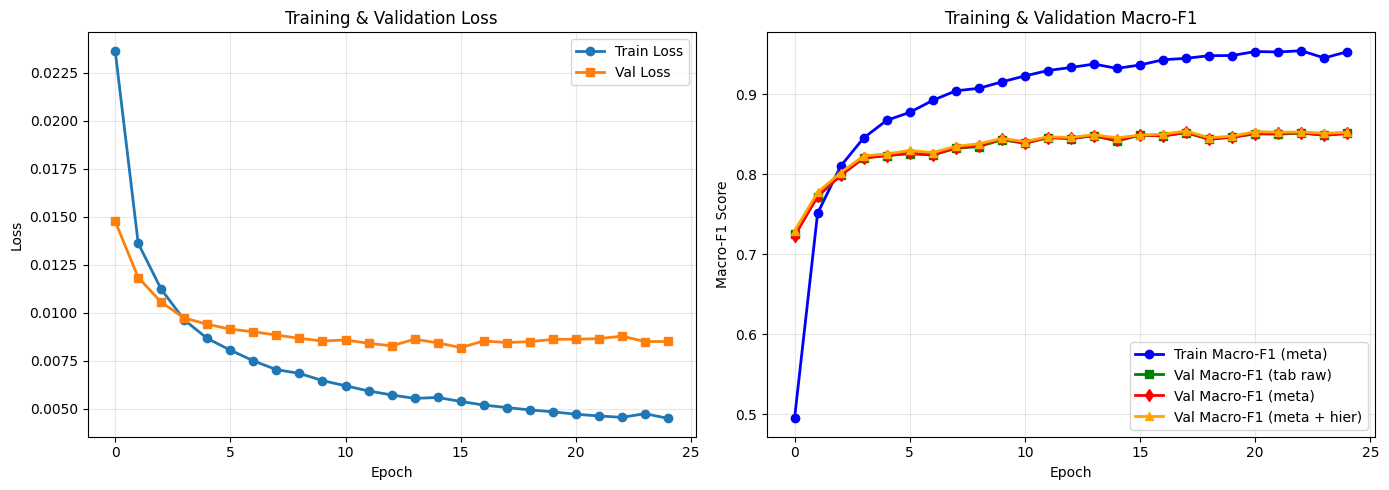

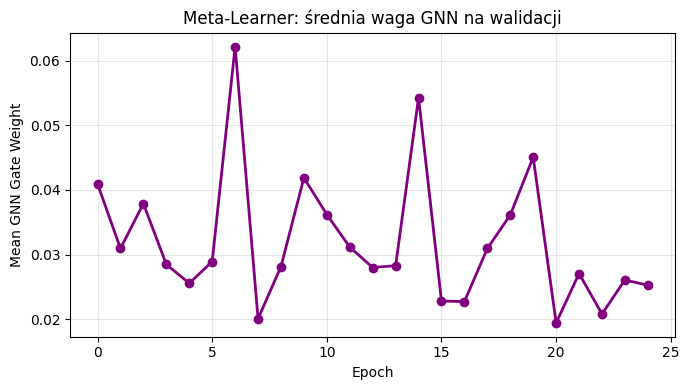

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# ---- Loss plot ----
plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="Train Loss", linewidth=2, marker="o")
plt.plot(history["val_loss"], label="Val Loss", linewidth=2, marker="s")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# ---- Macro-F1 plot ----
plt.subplot(1, 2, 2)
plt.plot(history["train_f1"], label="Train Macro-F1 (meta)", linewidth=2, marker="o", color="blue")
plt.plot(history["val_f1"], label="Val Macro-F1 (tab raw)", linewidth=2, marker="s", color="green")
if "val_f1_meta" in history:
    plt.plot(history["val_f1_meta"], label="Val Macro-F1 (meta)", linewidth=2, marker="d", color="red")
if "val_f1_hier" in history:
    plt.plot(history["val_f1_hier"], label="Val Macro-F1 (meta + hier)", linewidth=2, marker="^", color="orange")

plt.xlabel("Epoch")
plt.ylabel("Macro-F1 Score")
plt.title("Training & Validation Macro-F1")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history_with_f1.png", dpi=100, bbox_inches="tight")
plt.show()

if "val_gnn_weight_mean" in history:
    plt.figure(figsize=(7, 4))
    plt.plot(history["val_gnn_weight_mean"], linewidth=2, marker="o", color="purple")
    plt.xlabel("Epoch")
    plt.ylabel("Mean GNN Gate Weight")
    plt.title("Meta-Learner: średnia waga GNN na walidacji")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [18]:
# ============================================================
# Ensemble inference: HMCN(tabular) + GNN(graph) + Meta-learner + strict hierarchy repair
# ============================================================

# 1) Load test set (same schema as train)
test_df = pd.read_parquet("chebi_dataset_test_empty.parquet")
X_test_raw = test_df["SMILES"].tolist()

# 2) Filter invalid SMILES and keep mapping to original rows
X_test_clean, bad_idx_test = filter_invalid_smiles(X_test_raw, return_bad_indices=True)
print(f"Valid test molecules: {len(X_test_clean)} / {len(X_test_raw)}")

# 3) Build tabular features using the same generators as train
X_t_ecfp = load_or_transform_and_save(X_test_clean, ecfp_gen, "test_ecfp", "ecfp", dtype=np.uint8)
X_t_maccs = load_or_transform_and_save(X_test_clean, maccs_gen, "test_maccs", "maccs", dtype=np.uint8)
X_t_pubchem = load_or_transform_and_save(X_test_clean, pubchem_gen, "test_pubchem", "pubchem", dtype=np.uint8)
X_t_functional = load_or_transform_and_save(
    X_test_clean,
    functional_gen,
    "test_functional_groups",
    "functional_groups",
    dtype=np.uint8,
)
X_t_desc = load_or_transform_and_save(
    X_test_clean,
    desc_gen,
    "test_molecular_descriptors",
    "descriptor",
    dtype=np.float32,
    columns=desc_gen.feature_names,
)
X_t_smarts, _ = build_smarts_features(X_test_clean, smarts_patterns)
X_t_qed_fsp3, _ = build_qed_fsp3_features(X_test_clean)
test_feature_blocks = [X_t_ecfp, X_t_maccs, X_t_pubchem, X_t_functional, X_t_desc, X_t_qed_fsp3]
if X_t_smarts.shape[1] > 0:
    test_feature_blocks.append(X_t_smarts)
X_t_fp = np.hstack(test_feature_blocks).astype(np.float32)
X_t_scaled = scaler.transform(X_t_fp).astype(np.float32)

# Meta features dla gate (ten sam zestaw co w treningu)
meta_name_to_idx = {name: i for i, name in enumerate(desc_gen.feature_names)}
base_meta_from_desc_test = META_FEATURE_NAMES[:-2]
meta_desc_idx_test = np.array([meta_name_to_idx[name] for name in base_meta_from_desc_test], dtype=np.int64)
meta_x_test = np.hstack([X_t_desc[:, meta_desc_idx_test], X_t_qed_fsp3]).astype(np.float32)
X_t_meta = meta_scaler.transform(meta_x_test).astype(np.float32)

X_test_tensor = torch.from_numpy(X_t_scaled).to(device)
X_test_meta_tensor = torch.from_numpy(X_t_meta).to(device)

# 4) Build graph features for GNN branch in the same sample order
test_graphs = []
for s in X_test_clean:
    d = smiles_to_data(s)
    if d is None:
        raise RuntimeError("Found invalid graph in test_graphs after SMILES filtering.")
    test_graphs.append(d)

gnn_batch_size = int(BEST_PARAMS.get("batch_size", 128)) if "BEST_PARAMS" in globals() else 128
gnn_test_loader = GeometricDataLoader(test_graphs, batch_size=gnn_batch_size, shuffle=False)

# 5) Predict probabilities from both branches + dynamic gating
model.eval()
gnn_model.eval()
meta_learner.eval()

with torch.no_grad():
    tab_probs = model(X_test_tensor, apply_constraints=False)

    gnn_probs_list = []
    for batch in gnn_test_loader:
        batch = batch.to(device)
        gnn_batch_probs = gnn_model(batch)
        gnn_probs_list.append(gnn_batch_probs)
    gnn_probs = torch.cat(gnn_probs_list, dim=0)

if tab_probs.shape != gnn_probs.shape:
    raise RuntimeError(f"Shape mismatch tab_probs={tuple(tab_probs.shape)}, gnn_probs={tuple(gnn_probs.shape)}")

# 6) Dynamic fusion by Meta-learner
probs_clean_t, gnn_gate_weight_t = meta_learner(tab_probs, gnn_probs, X_test_meta_tensor)
probs_clean = probs_clean_t.detach().cpu().numpy()

print(
    f"Meta gate stats (GNN weight) -> min: {gnn_gate_weight_t.min().item():.3f}, "
    f"max: {gnn_gate_weight_t.max().item():.3f}, mean: {gnn_gate_weight_t.mean().item():.3f}"
)

# 7) Thresholding (from tuned best params if available)
best_threshold = float(BEST_PARAMS.get("threshold", 0.5)) if "BEST_PARAMS" in globals() else 0.5
preds_clean = (probs_clean > best_threshold).astype(int)
print(f"Using decision threshold: {best_threshold:.4f}")

# 8) Tie-breaker AFTER thresholding
def apply_hierarchy_tiebreaker(preds_binary, probs, hierarchy_children):
    fixed = preds_binary.copy().astype(np.int32)
    for parent_idx, children_indices in enumerate(hierarchy_children):
        if not children_indices:
            continue

        for child_idx in children_indices:
            conflict = (fixed[:, child_idx] == 1) & (fixed[:, parent_idx] == 0)
            if not np.any(conflict):
                continue

            idx = np.where(conflict)[0]
            parent_prob = probs[idx, parent_idx]
            child_prob = probs[idx, child_idx]

            keep_child = child_prob > parent_prob
            if np.any(keep_child):
                fixed[idx[keep_child], parent_idx] = 1
            if np.any(~keep_child):
                fixed[idx[~keep_child], child_idx] = 0

    return fixed


preds_clean = apply_hierarchy_tiebreaker(preds_clean, probs_clean, hierarchy_children)

# 9) Strict binary hierarchy repair (iterative)
def strict_hierarchy_repair_binary(preds_binary, hierarchy_children):
    fixed = preds_binary.copy().astype(np.int32)
    changed = True
    while changed:
        changed = False
        for parent_idx, children_indices in enumerate(hierarchy_children):
            if not children_indices:
                continue
            child_active = fixed[:, children_indices].max(axis=1)
            need_parent = (child_active == 1) & (fixed[:, parent_idx] == 0)
            if np.any(need_parent):
                fixed[need_parent, parent_idx] = 1
                changed = True
    return fixed


preds_clean = strict_hierarchy_repair_binary(preds_clean, hierarchy_children)

# 10) Validate zero hierarchy violations
violations = 0
for parent_idx, children_indices in enumerate(hierarchy_children):
    for child_idx in children_indices:
        violations += np.sum((preds_clean[:, child_idx] == 1) & (preds_clean[:, parent_idx] == 0))

if violations != 0:
    raise RuntimeError(f"Hierarchy repair failed, found {violations} violations after strict repair.")

print("✓ Strict hierarchy repair completed: 0 violations.")

# 11) Rebuild full-size matrix with zeros for invalid SMILES
preds_full = np.zeros((len(X_test_raw), len(target_cols)), dtype=int)
if len(bad_idx_test) > 0:
    bad_idx_set = set(bad_idx_test.tolist())
else:
    bad_idx_set = set()
good_idx_test = [i for i in range(len(X_test_raw)) if i not in bad_idx_set]

for i, row_idx in enumerate(good_idx_test):
    preds_full[row_idx, :] = preds_clean[i, :]

final_predictions = preds_full

# 12) Save CSV submission (mol_id + labels)
submission_csv = pd.DataFrame(final_predictions, columns=target_cols)
submission_csv.insert(0, "mol_id", test_df["mol_id"].values)
submission_csv.to_csv("submission.csv", index=False)

print("✅ submission.csv generated successfully")
print(f"Submission shape: {submission_csv.shape}")
print(f"Positive labels predicted: {final_predictions.sum()}")

Filtrowanie: 11223 -> 11221
Valid test molecules: 11221 / 11223
[LOAD] test_ecfp: (11221, 2048) <- fingerprint_csv_cache/test_ecfp.csv
[LOAD] test_maccs: (11221, 166) <- fingerprint_csv_cache/test_maccs.csv
[LOAD] test_pubchem: (11221, 881) <- fingerprint_csv_cache/test_pubchem.csv
[LOAD] test_functional_groups: (11221, 85) <- fingerprint_csv_cache/test_functional_groups.csv
[LOAD] test_molecular_descriptors: (11221, 29) <- fingerprint_csv_cache/test_molecular_descriptors.csv
[BUILD] smarts: (11221, 71)
[BUILD] qed_fsp3: (11221, 2)
Meta gate stats (GNN weight) -> min: 0.000, max: 0.694, mean: 0.027
Using decision threshold: 0.5277
✓ Strict hierarchy repair completed: 0 violations.
✅ submission.csv generated successfully
Submission shape: (11223, 501)
Positive labels predicted: 315143


In [19]:
submission = pd.DataFrame(final_predictions, columns=target_cols)
submission.insert(0, "SMILES", test_df["SMILES"].values)
submission.insert(0, "mol_id", test_df["mol_id"].values)
print("Pierwsze 5 kolumn:", submission.columns[:5].tolist())
submission.to_parquet("chebi_submission_example.parquet")
print("SUKCES! Plik chebi_submission.parquet gotowy.")

Pierwsze 5 kolumn: ['mol_id', 'SMILES', 'class_0', 'class_1', 'class_2']
SUKCES! Plik chebi_submission.parquet gotowy.
